# 1 · Exploratory Data Analysis — The Mimicry Gap

**Measuring Pragmatic Alignment in LLM-Based Agents**  
University of Trier · NLP Master's Program · WS 2025/26

This notebook analyses 1,000 English political-discourse samples from X (Twitter), comparing **authentic human replies** against **Qwen3 8B fine-tuned replies** for the same target tweet.

| Step | What it does |
|------|-------------|
| 1 | Data loading & overview |
| 2 | Context parsing — extract target tweets |
| 3 | Text length statistics |
| 4 | Lexical analysis (TTR + Jaccard overlap) |
| 5 | Sentiment & POS analysis (VADER + NLTK) |
| 6 | Semantic similarity (SBERT cosine) |
| 7 | Baseline classifier — distinguishability test |

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import ast
import re
import string
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# ── NLTK resource downloads (skipped if already cached) ───────────────────────
for _path, _pkg in [
    ("tokenizers/punkt",                      "punkt"),
    ("tokenizers/punkt_tab",                  "punkt_tab"),
    ("corpora/stopwords",                      "stopwords"),
    ("sentiment/vader_lexicon.zip",            "vader_lexicon"),
    ("taggers/averaged_perceptron_tagger",     "averaged_perceptron_tagger"),
    ("taggers/averaged_perceptron_tagger_eng", "averaged_perceptron_tagger_eng"),
]:
    try:
        nltk.data.find(_path)
    except LookupError:
        nltk.download(_pkg, quiet=True)

warnings.filterwarnings("ignore")
print("Imports ready.")

Imports ready.


In [2]:
# ── Paths & plotting config ────────────────────────────────────────────────────
DATA_PATH = Path("../data/dataset.english.csv")
PLOTS_DIR = Path("../data/processed/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (12, 5)})

---
## 1. Data Loading & Overview

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
df.head(2)

Shape   : (1000, 5)
Columns : ['prompt', 'authentic_reply', 'base_model_reply', 'base_model_thinking_reply', 'ft_model_reply']


,prompt,authentic_reply,base_model_reply,base_model_thinking_reply,ft_model_reply
0,"[{'role': 'system', 'content': ""You are a soci...","@AoDespair In hindsight, the craziest thing ab...",@AoDespair And now it's a full-blown mafia sag...,"@AoDespair That ""light little romp"" in New Yor...",@AoDespair @mattmcdonalds12949107 You really t...
1,"[{'role': 'system', 'content': ""You are a soci...","@catturd2 Ok, that one was funny.",@catturd2 Breaking... \n\nMerrick Garland has ...,@iamAtheistGirl I've never once felt attacked ...,@catturd2 BREAKING... \n\nMerrick Garland has ...


---
## 2. Context Parsing — Extract Target Tweets

The `prompt` column stores a serialised list of chat turns.  
We extract the last `user` turn as the *target tweet* the model was asked to reply to.

In [4]:
def extract_target_tweet(prompt_str: str) -> str | None:
    """Return the content of the last user turn in the serialised prompt."""
    try:
        turns = ast.literal_eval(prompt_str)
        for turn in reversed(turns):
            if turn.get("role") == "user":
                return turn.get("content")
    except (ValueError, SyntaxError):
        pass
    return None

df["target_tweet"] = df["prompt"].apply(extract_target_tweet)
print(f"Extracted target_tweet for {df['target_tweet'].notna().sum()} / {len(df)} rows.")
df[["target_tweet", "authentic_reply", "ft_model_reply"]].head(3)

Extracted target_tweet for 1000 / 1000 rows.


,target_tweet,authentic_reply,ft_model_reply
0,>AoDespair: The thing I think we all should ac...,"@AoDespair In hindsight, the craziest thing ab...",@AoDespair @mattmcdonalds12949107 You really t...
1,>catturd2: Breaking ... \n\nMerrick Garland ha...,"@catturd2 Ok, that one was funny.",@catturd2 BREAKING... \n\nMerrick Garland has ...
2,">cmclymer: ""I don't think Joe Biden gets enoug...",@cmclymer Anyone listening to Rachel Maddow an...,@cmclymer It was a very well thought out plan.


---
## 3. Text Length Statistics

Are the two reply corpora similar in overall length?

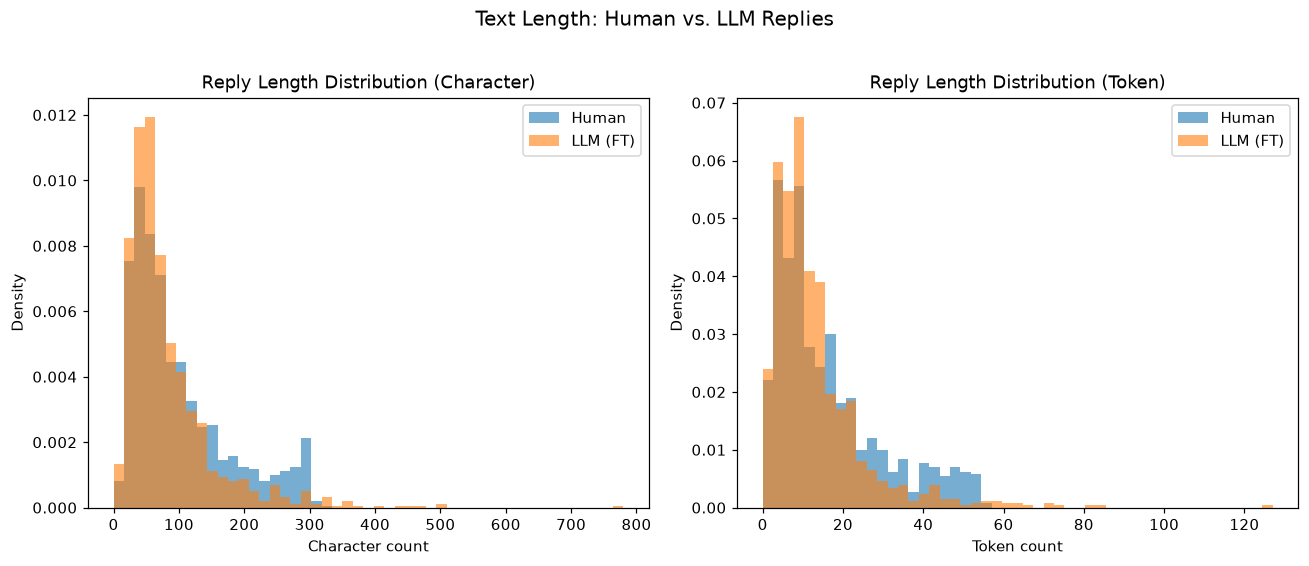

       auth_char_len  ft_char_len  auth_token_len  ft_token_len
count         1000.0       1000.0          1000.0        1000.0
mean           100.5         82.4            16.3          13.1
std             76.1         70.7            13.3          11.8
min              6.0          8.0             2.0           2.0
25%             43.0         40.0             6.0           6.0
50%             73.0         61.0            12.0          10.0
75%            139.0        100.0            22.0          16.0
max            324.0        780.0            57.0         127.0


In [5]:
df.dropna(subset=["authentic_reply", "ft_model_reply"], inplace=True)

df["auth_char_len"]  = df["authentic_reply"].str.len()
df["ft_char_len"]    = df["ft_model_reply"].str.len()
df["auth_token_len"] = df["authentic_reply"].apply(lambda x: len(str(x).split()))
df["ft_token_len"]   = df["ft_model_reply"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2)
for ax, metric, label in [
    (axes[0], "char",  "Character"),
    (axes[1], "token", "Token"),
]:
    max_val = max(df[f"auth_{metric}_len"].max(), df[f"ft_{metric}_len"].max())
    bins    = np.linspace(0, max_val, 50)
    ax.hist(df[f"auth_{metric}_len"], bins=bins, alpha=0.6, density=True, label="Human")
    ax.hist(df[f"ft_{metric}_len"],   bins=bins, alpha=0.6, density=True, label="LLM (FT)")
    ax.set_title(f"Reply Length Distribution ({label})")
    ax.set_xlabel(f"{label} count")
    ax.set_ylabel("Density")
    ax.legend()
plt.suptitle("Text Length: Human vs. LLM Replies", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "length_distribution.png", bbox_inches="tight")
plt.show()

print(df[["auth_char_len", "ft_char_len", "auth_token_len", "ft_token_len"]].describe().round(1))

> **Finding:** Humans write longer replies on average (mean ~100 chars vs. ~82 for LLM), but the LLM has a longer tail — it occasionally produces very verbose outliers.

---
## 4. Lexical Analysis — Diversity & Overlap

Do the two corpora share vocabulary, or do they use completely different words to address the same tweet?

Type-Token Ratio  (higher = more diverse vocabulary)
  Human    : 0.4072
  LLM (FT) : 0.3401

Calculating per-pair Jaccard similarity...



Jaccard similarity statistics:
count    1000.0000
mean        0.0218
std         0.0844
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max         1.0000
Name: jaccard, dtype: float64


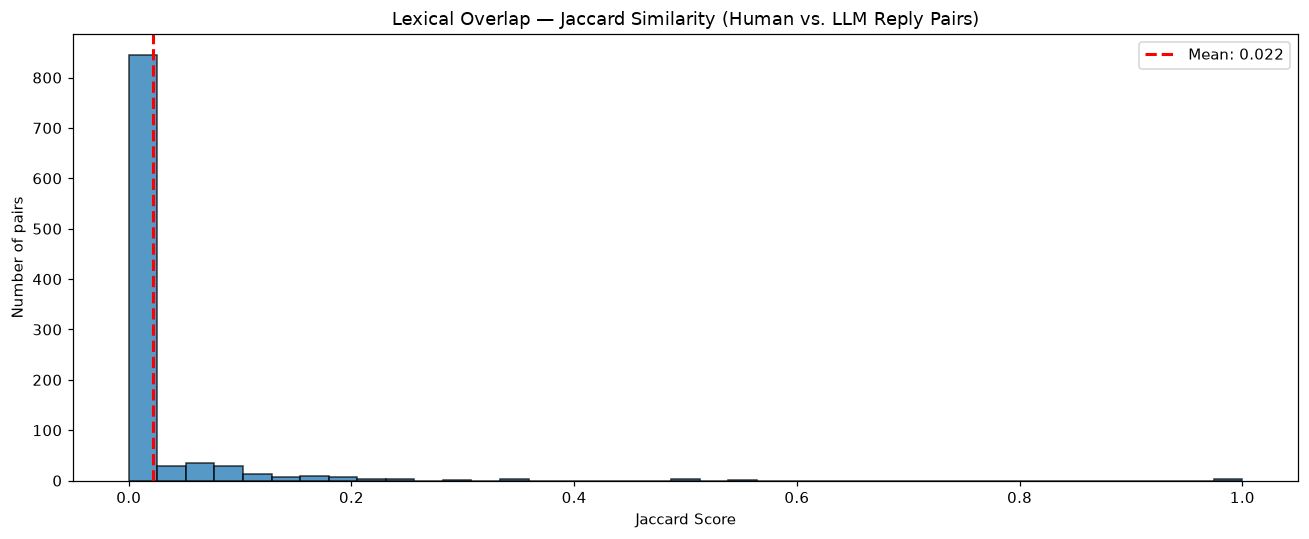

In [6]:
STOP_WORDS = set(stopwords.words("english"))

def clean_tokens(text: str) -> list[str]:
    """Lowercase, strip @handles and RT, tokenise, remove stopwords & punctuation."""
    if not isinstance(text, str):
        return []
    text = re.sub(r"@\w+", "", text.lower())
    text = re.sub(r"\brt\b",  "", text)
    return [t for t in word_tokenize(text) if t.isalpha() and t not in STOP_WORDS]

def type_token_ratio(tokens: list[str]) -> float:
    """Unique tokens / total tokens (higher = richer vocabulary)."""
    return len(set(tokens)) / len(tokens) if tokens else 0.0

def jaccard(t1: str, t2: str) -> float:
    """Word-level Jaccard similarity after cleaning."""
    s1, s2 = set(clean_tokens(t1)), set(clean_tokens(t2))
    union  = s1 | s2
    return len(s1 & s2) / len(union) if union else 0.0

all_auth = df["authentic_reply"].apply(clean_tokens).sum()
all_ft   = df["ft_model_reply"].apply(clean_tokens).sum()

print("Type-Token Ratio  (higher = more diverse vocabulary)")
print(f"  Human    : {type_token_ratio(all_auth):.4f}")
print(f"  LLM (FT) : {type_token_ratio(all_ft):.4f}")

print("\nCalculating per-pair Jaccard similarity...")
df["jaccard"] = df.apply(
    lambda row: jaccard(row["authentic_reply"], row["ft_model_reply"]), axis=1
)

print(f"\nJaccard similarity statistics:")
print(df["jaccard"].describe().round(4))

plt.figure()
plt.hist(df["jaccard"], bins=np.linspace(0, 1, 40), alpha=0.75, edgecolor="black")
plt.axvline(df["jaccard"].mean(), color="red", linestyle="--", linewidth=2,
            label=f"Mean: {df['jaccard'].mean():.3f}")
plt.title("Lexical Overlap — Jaccard Similarity (Human vs. LLM Reply Pairs)")
plt.xlabel("Jaccard Score")
plt.ylabel("Number of pairs")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "jaccard_similarity.png")
plt.show()

> **Finding:** Mean Jaccard ~2%. The 75th percentile is 0.0 — at least 75% of reply pairs share *zero* meaningful keywords. The LLM addresses the same tweets using an almost completely different vocabulary.

---
## 5. Sentiment & POS Analysis

If the lexical content is so different, do the two corpora share the same *style* — emotional tone and grammatical structure?

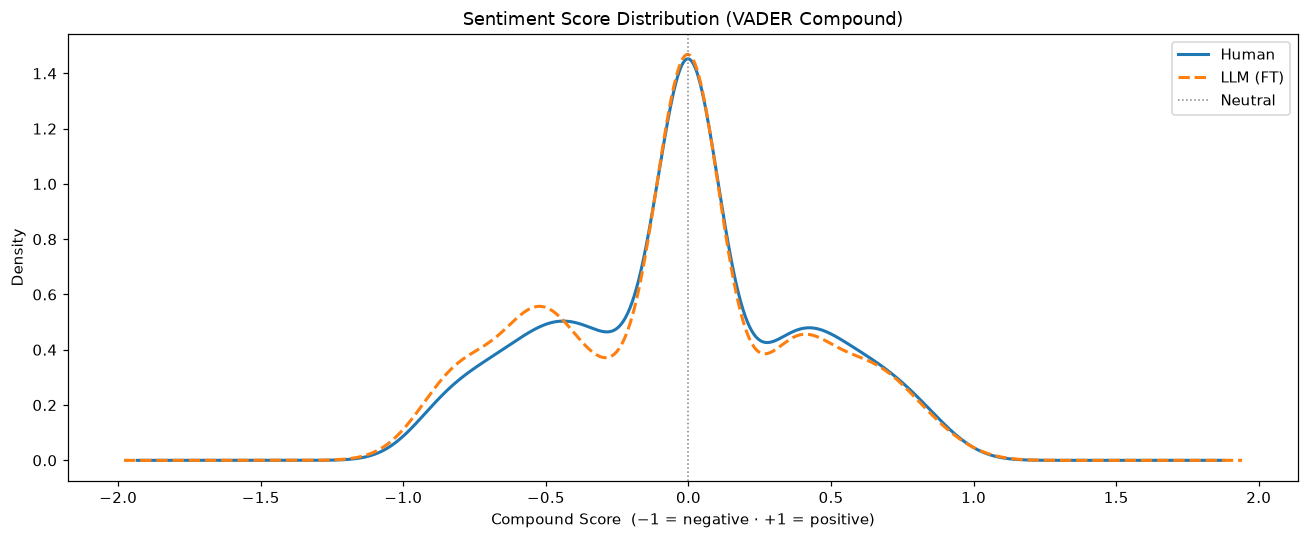

       auth_sentiment  ft_sentiment
count        1000.000      1000.000
mean           -0.028        -0.055
std             0.428         0.441
min            -0.981        -0.999
25%            -0.340        -0.422
50%             0.000         0.000
75%             0.273         0.202
max             0.925         0.961


In [7]:
# ── VADER sentiment ────────────────────────────────────────────────────────────
sid = SentimentIntensityAnalyzer()

df["auth_sentiment"] = df["authentic_reply"].apply(
    lambda x: sid.polarity_scores(str(x))["compound"]
)
df["ft_sentiment"] = df["ft_model_reply"].apply(
    lambda x: sid.polarity_scores(str(x))["compound"]
)

plt.figure()
df["auth_sentiment"].plot(kind="kde", label="Human",    linewidth=2)
df["ft_sentiment"].plot(  kind="kde", label="LLM (FT)", linewidth=2, linestyle="--")
plt.axvline(0, color="gray", linestyle=":", linewidth=1, label="Neutral")
plt.title("Sentiment Score Distribution (VADER Compound)")
plt.xlabel("Compound Score  (−1 = negative · +1 = positive)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "sentiment_distribution.png")
plt.show()

print(df[["auth_sentiment", "ft_sentiment"]].describe().round(3))

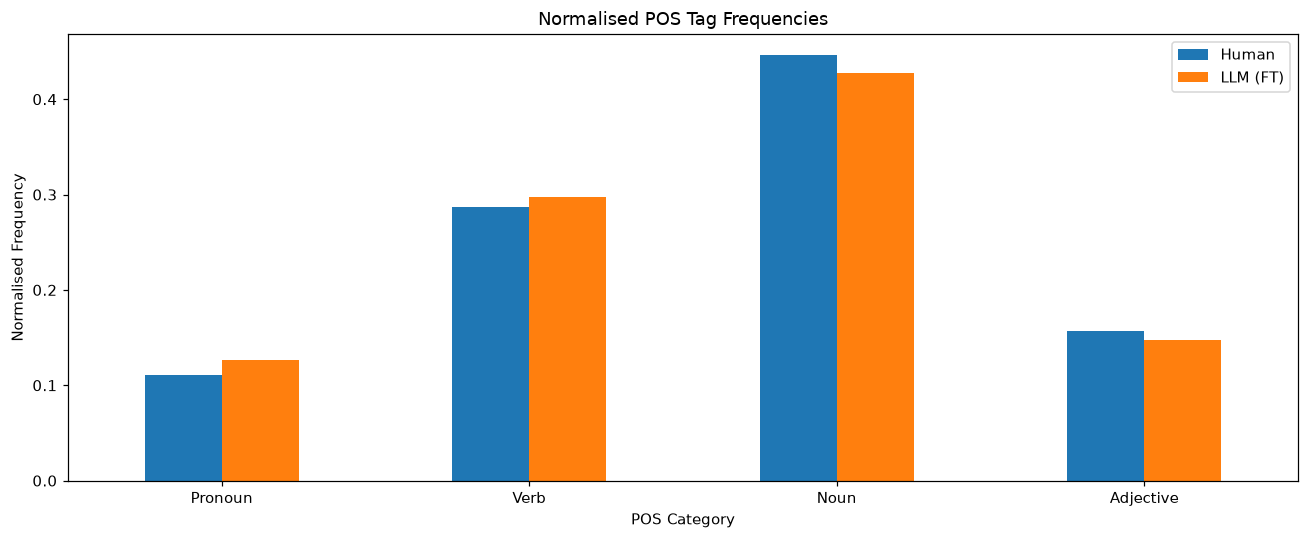

            Human  LLM (FT)
Pronoun    0.1111    0.1269
Verb       0.2865    0.2977
Noun       0.4459    0.4277
Adjective  0.1565    0.1477


In [8]:
# ── POS tag frequencies ────────────────────────────────────────────────────────
POS_MAP = {"PRP": "Pronoun", "VB": "Verb", "NN": "Noun", "JJ": "Adjective"}

def pos_counts(text: str) -> Counter:
    if not isinstance(text, str):
        return Counter()
    counts = Counter()
    for _, tag in nltk.pos_tag(word_tokenize(text.lower())):
        for prefix, label in POS_MAP.items():
            if tag.startswith(prefix):
                counts[label] += 1
    return counts

auth_pos = sum(df["authentic_reply"].apply(pos_counts), Counter())
ft_pos   = sum(df["ft_model_reply"].apply(pos_counts),  Counter())

tot_a = sum(auth_pos.values()) or 1
tot_f = sum(ft_pos.values())   or 1

pos_df = pd.DataFrame({
    "Human":    {k: auth_pos[k] / tot_a for k in POS_MAP.values()},
    "LLM (FT)": {k: ft_pos[k]  / tot_f for k in POS_MAP.values()},
})

pos_df.plot(kind="bar", rot=0)
plt.title("Normalised POS Tag Frequencies")
plt.xlabel("POS Category")
plt.ylabel("Normalised Frequency")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "pos_distribution.png")
plt.show()

print(pos_df.round(4))

> **Finding:** Sentiment distributions and POS frequencies are near-identical. The LLM has learned to *sound* like a human tweeter (matching emotional tone and grammatical rhythm) even though the words themselves are almost entirely different.

---
## 6. Semantic Similarity (SBERT)

`all-MiniLM-L6-v2` (384-d) cosine similarity measures meaning-level alignment between each authentic–LLM reply pair.

Loading SBERT model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding authentic replies...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Encoding LLM replies...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


Semantic similarity statistics:
count    1000.000
mean        0.456
std         0.191
min        -0.012
25%         0.324
50%         0.451
75%         0.576
max         1.000
Name: semantic_sim, dtype: float64


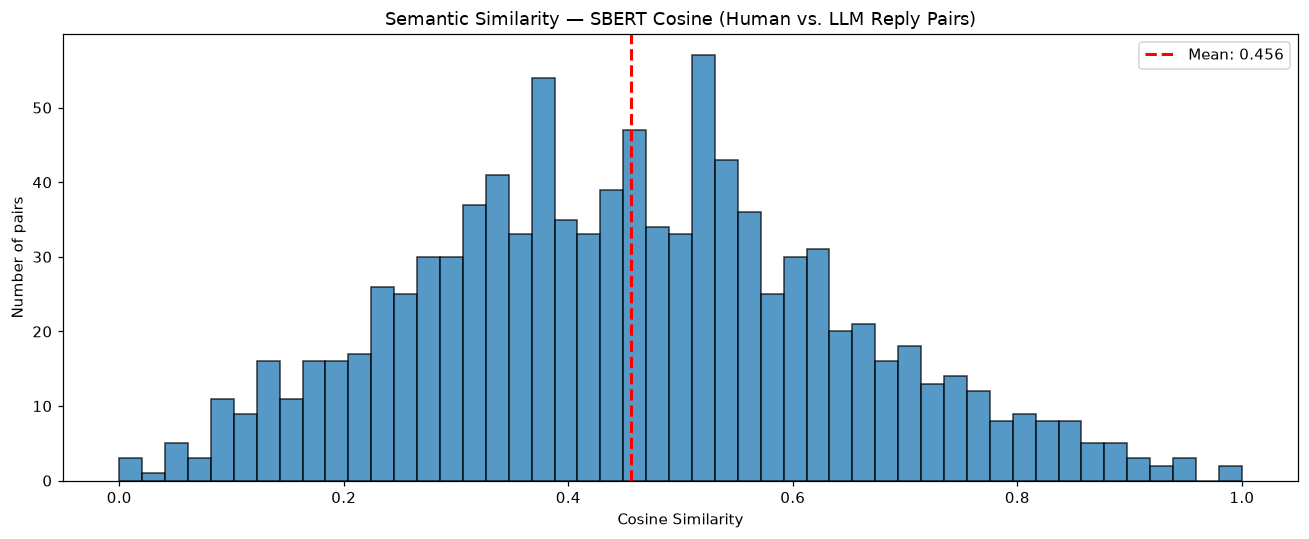

In [9]:
print("Loading SBERT model (all-MiniLM-L6-v2)...")
sbert = SentenceTransformer("all-MiniLM-L6-v2")

auth_replies = df["authentic_reply"].astype(str).tolist()
ft_replies   = df["ft_model_reply"].astype(str).tolist()

print("Encoding authentic replies...")
auth_emb = sbert.encode(auth_replies, show_progress_bar=True, convert_to_tensor=True)
print("Encoding LLM replies...")
ft_emb   = sbert.encode(ft_replies,   show_progress_bar=True, convert_to_tensor=True)

df["semantic_sim"] = [
    util.cos_sim(auth_emb[i], ft_emb[i]).item() for i in range(len(df))
]

print("\nSemantic similarity statistics:")
print(df["semantic_sim"].describe().round(3))

plt.figure()
plt.hist(df["semantic_sim"], bins=np.linspace(0, 1, 50), alpha=0.75, edgecolor="black")
plt.axvline(df["semantic_sim"].mean(), color="red", linestyle="--", linewidth=2,
            label=f"Mean: {df['semantic_sim'].mean():.3f}")
plt.title("Semantic Similarity — SBERT Cosine (Human vs. LLM Reply Pairs)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of pairs")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "semantic_similarity.png")
plt.show()

> **Finding:** Mean cosine ~0.45. The LLM is not merely paraphrasing the human reply — it is often expressing a *different message* in response to the same tweet. This explains the Jaccard paradox: different words because different meaning, not just different phrasing.

---
## 7. Distinguishability — can anything tell the two apart?

Section 4 showed the two corpora share almost no vocabulary; section 5 showed
they share almost identical style. So: is the fine-tuned model's output actually
*detectable* as machine-written?

This matters beyond curiosity. A reliable human-vs-machine detector is the only
way to check, later in the pipeline, whether steering a model toward pragmatic
targets is making its output *less* human-like. We therefore test five detectors
of increasing power rather than one, and we test them against **both** the
fine-tuned model and the base model it was fine-tuned from.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import joblib

def stylometry(texts):
    """Surface style features: length, vocabulary variety, punctuation, casing."""
    rows = []
    for t in texts:
        t = str(t)
        words = t.split()
        rows.append([
            len(t),
            len(words),
            np.mean([len(w) for w in words]) if words else 0,
            len(set(words)) / len(words) if words else 0,   # within-reply type-token ratio
            t.count("!"), t.count("?"), t.count("@"), t.count("#"), t.count("..."),
            sum(c.isupper() for c in t) / max(len(t), 1),
            sum(c.isdigit() for c in t) / max(len(t), 1),
            len(re.findall(r"[^\w\s,.!?@#]", t)) / max(len(t), 1),
        ])
    return np.array(rows)

def compare_detectors(machine_texts, label):
    """Train four detectors to separate human replies from `machine_texts`."""
    texts = df["authentic_reply"].astype(str).tolist() + [str(t) for t in machine_texts]
    y = np.array([0] * len(df) + [1] * len(machine_texts))
    i_tr, i_te = train_test_split(
        np.arange(len(y)), test_size=0.25, random_state=42, stratify=y
    )

    emb = sbert.encode(texts, batch_size=128, show_progress_bar=False)
    sty = stylometry(texts)
    sty_scaled = StandardScaler().fit(sty[i_tr]).transform(sty)

    tfidf = TfidfVectorizer(stop_words="english", max_features=5_000)
    tf_tr = tfidf.fit_transform([texts[i] for i in i_tr])
    tf_te = tfidf.transform([texts[i] for i in i_te])

    results, fitted = {}, {}
    for name, Xtr, Xte in [
        ("TF-IDF (word choice)", tf_tr, tf_te),
        ("Stylometry", sty_scaled[i_tr], sty_scaled[i_te]),
        ("SBERT embeddings", emb[i_tr], emb[i_te]),
        ("SBERT + stylometry",
         np.hstack([emb, sty_scaled])[i_tr], np.hstack([emb, sty_scaled])[i_te]),
    ]:
        clf = LogisticRegression(max_iter=3000, random_state=42).fit(Xtr, y[i_tr])
        proba = clf.predict_proba(Xte)[:, 1]
        results[name] = {
            "Accuracy": accuracy_score(y[i_te], proba > 0.5),
            "AUC": roc_auc_score(y[i_te], proba),
        }
        fitted[name] = clf

    print(f"\n=== human vs {label} (n={len(y)}, {len(i_te)} held out) ===")
    print(pd.DataFrame(results).T.round(4).to_string())
    return results, fitted, (emb, sty_scaled, y, i_tr, i_te)

res_ft, fitted_ft, ft_data = compare_detectors(df["ft_model_reply"], "FINE-TUNED Qwen")
res_base, _, _ = compare_detectors(df["base_model_reply"], "BASE Qwen (not fine-tuned)")

print("\n\nTF-IDF accuracy, base vs fine-tuned model:")
print(f"  detecting the BASE model       : {res_base['TF-IDF (word choice)']['Accuracy']:.4f}")
print(f"  detecting the FINE-TUNED model : {res_ft['TF-IDF (word choice)']['Accuracy']:.4f}")


=== human vs FINE-TUNED Qwen (n=2000, 500 held out) ===
                      Accuracy     AUC
TF-IDF (word choice)     0.496  0.5430
Stylometry               0.656  0.7147
SBERT embeddings         0.660  0.7002
SBERT + stylometry       0.692  0.7608



=== human vs BASE Qwen (not fine-tuned) (n=2000, 500 held out) ===
                      Accuracy     AUC
TF-IDF (word choice)     0.778  0.8402
Stylometry               0.712  0.7744
SBERT embeddings         0.754  0.8298
SBERT + stylometry       0.772  0.8436


TF-IDF accuracy, base vs fine-tuned model:
  detecting the BASE model       : 0.7780
  detecting the FINE-TUNED model : 0.4960


A logistic-regression head on frozen features is a weak detector. The strongest
test available is to fine-tune a small transformer end-to-end on the same task.

In [11]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
DETECTOR_MODEL = "distilroberta-base"
torch.manual_seed(42)

texts_ft = df["authentic_reply"].astype(str).tolist() + df["ft_model_reply"].astype(str).tolist()
y_ft = np.array([0] * len(df) + [1] * len(df))
i_tr, i_te = train_test_split(np.arange(len(y_ft)), test_size=0.25, random_state=42, stratify=y_ft)

tok = AutoTokenizer.from_pretrained(DETECTOR_MODEL)

class ReplyDataset(Dataset):
    def __init__(self, idx):
        self.idx = idx
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, k):
        j = self.idx[k]
        enc = tok(texts_ft[j], truncation=True, padding="max_length",
                  max_length=96, return_tensors="pt")
        item = {a: b.squeeze(0) for a, b in enc.items()}
        item["labels"] = torch.tensor(int(y_ft[j]))
        return item

class Detector(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(DETECTOR_MODEL)
        self.dropout = torch.nn.Dropout(0.1)
        self.head = torch.nn.Linear(self.encoder.config.hidden_size, 2)
    def forward(self, input_ids, attention_mask, **kw):
        pooled = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0]
        return self.head(self.dropout(pooled))

detector = Detector().to(DEVICE)
optim = torch.optim.AdamW(detector.parameters(), lr=2e-5, weight_decay=0.01)
loss_fn = torch.nn.CrossEntropyLoss()
train_dl = DataLoader(ReplyDataset(i_tr), batch_size=16, shuffle=True)
test_dl = DataLoader(ReplyDataset(i_te), batch_size=32)

for epoch in range(4):
    detector.train()
    for batch in train_dl:
        labels = batch.pop("labels").to(DEVICE)
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optim.zero_grad()
        loss_fn(detector(**batch), labels).backward()
        optim.step()
    detector.eval()
    probs = []
    with torch.no_grad():
        for batch in test_dl:
            batch.pop("labels")
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            probs.append(torch.softmax(detector(**batch), -1)[:, 1].cpu().numpy())
    probs = np.concatenate(probs)
    print(f"  epoch {epoch + 1}  accuracy {accuracy_score(y_ft[i_te], probs > 0.5):.4f}"
          f"   AUC {roc_auc_score(y_ft[i_te], probs):.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1  accuracy 0.6920   AUC 0.8243


  epoch 2  accuracy 0.7440   AUC 0.8460


  epoch 3  accuracy 0.7480   AUC 0.8405


  epoch 4  accuracy 0.7600   AUC 0.8526


The `SBERT + stylometry` detector is serialised for use in notebook 3, where it
measures whether pragmatic steering pushes generated replies away from human
style. It is chosen over the fine-tuned transformer because it is small, exactly
reproducible and adds no model weights to the repository.

In [12]:
emb_all, sty_all, y_all, i_tr_all, i_te_all = ft_data
X_all = np.hstack([emb_all, sty_all])
humanness = LogisticRegression(max_iter=3000, random_state=42).fit(X_all[i_tr_all], y_all[i_tr_all])
proba = humanness.predict_proba(X_all[i_te_all])[:, 1]
print(f"saved detector — accuracy {accuracy_score(y_all[i_te_all], proba > 0.5):.4f}"
      f"  AUC {roc_auc_score(y_all[i_te_all], proba):.4f}")

scaler = StandardScaler().fit(stylometry(
    df["authentic_reply"].astype(str).tolist() + df["ft_model_reply"].astype(str).tolist()
))
joblib.dump({"clf": humanness, "scaler": scaler}, "humanness_detector.pkl")
print("humanness detector -> notebooks/humanness_detector.pkl")

human_sty = stylometry(df["authentic_reply"].astype(str).tolist())
print("\nHuman reference style (used as the target distribution in notebook 3):")
print(f"  characters       mean {human_sty[:, 0].mean():.1f}  sd {human_sty[:, 0].std():.1f}")
print(f"  words            mean {human_sty[:, 1].mean():.1f}  sd {human_sty[:, 1].std():.1f}")
print(f"  within-reply TTR mean {human_sty[:, 3].mean():.3f}  sd {human_sty[:, 3].std():.3f}")
print("  (within-reply TTR is per-reply repetition; the corpus-level figure in section 4 is a different measure)")

saved detector — accuracy 0.6920  AUC 0.7608
humanness detector -> notebooks/humanness_detector.pkl

Human reference style (used as the target distribution in notebook 3):
  characters       mean 100.5  sd 76.1
  words            mean 16.3  sd 13.3
  within-reply TTR mean 0.966  sd 0.059
  (within-reply TTR is per-reply repetition; the corpus-level figure in section 4 is a different measure)


---
## Summary — The Mimicry Gap

| Metric | Result | Interpretation |
|--------|--------|----------------|
| TF-IDF detector, base model | ~0.78 | Word choice alone exposes the un-tuned model |
| TF-IDF detector, fine-tuned model | ~0.50 | Fine-tuning erased the lexical fingerprint entirely |
| Stylometry detector | ~0.66 | Length and vocabulary variety still leak |
| Fine-tuned transformer detector | ~0.76 | Deeper structure remains machine-like |
| Jaccard overlap | 0.022 (median 0.000) | Lexical content is almost entirely different |
| Semantic similarity | 0.456 | Meaning is only moderately aligned |
| Sentiment / POS | Near-identical | Style is well-calibrated |

**Conclusion.** Fine-tuning succeeded at the surface level and failed below it.
A word-frequency classifier that spots the base model three times out of four is
reduced to chance against the fine-tuned model — its vocabulary signature is
gone. Yet a fine-tuned transformer still identifies that same output as machine-
written about 76% of the time, and simple stylometric features alone manage 66%.

The machine-ness did not disappear; it moved out of word choice and into
structure and phrasing. Combined with a Jaccard overlap near zero and a semantic
similarity of only 0.46, the model is answering the same tweets with different
words *and* a different message, while matching human sentiment and grammar.

This is the **Mimicry Gap**: stylistic alignment without functional equivalence.
Detecting it needs the multi-dimensional pragmatic annotation scheme (Stance,
Action, Personalness, Politeness) developed in the next notebook.